# Example 5:  Modelling of an oxidation experiment

This benchmark describes the simulation of an oxidation experiment with marine pyrite-containing sediments. This modelling study was, together with the experimental work, originally reported by Appelo et al. (1998). The conceptual hydrochemical model and the implemented reaction network proposed for this experiment consists of a complex set of reactive processes. This includes

- the oxidation of pyrite, which is the primary driver of hydrochemical changes
- secondary reactions, such as dissolution of calcite, CO2 sorption, cation and proton exchange and
- oxidation of organic matter, a reaction that competes for the oxidation capacity supplied by the inflow solution. 

The modelling study considers three distinct phases of the experiment. In the first part the sediment material collected in the field was equilibrated with a 280 mmol MgCl<sub>2</sub> solution. In this phase the pore space becomes completely filled with the MgCl<sub>2</sub> solution and the exchangers sites are filled with Mg. In the second phase the column was fed with a more dilute MgCl<sub>2</sub> solution, while in the third phase the column was flushed for 4 pore volumes (at the same flow rate) with a hydrogen peroxide (H<sub>2</sub>O<sub>2</sub>) containing oxidising solution. Particularely the second phase provided the data that allowed to characterise the non-reactive transport  behaviour.

In [1]:
# import libraries
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# add mf6rtm path to the system
import flopy
from mf6rtm import utils, mup3d
import difflib

In [2]:
# project prefix for inputs and outputs
prefix = 'ex5'
DT_FMT = "%Y-%m-%d %H:%M:%S"

repo_path = Path.cwd().parent.parent
working_directory = repo_path / "benchmark" / prefix / 'mf6rtm'
dataws = repo_path / "benchmark" / "data"
databasews = repo_path / "benchmark" / "database"

In [3]:


# functions to compare outputs from pht3d and mf6rtm
def find_closest_match(query, dictionary):
    closest_match = difflib.get_close_matches(query, dictionary.keys(), n=1)
    if closest_match:
        return closest_match[0]
    else:
        return None
    
def calc_rows_from_ncol(variables, ncols=4):
    '''
    Calculates number of rows for subplots
    from ncols and len of variables to plot.

    Parameters:
        variables (list or sequence): list of variables to plot
        ncols (int): number of columns to plot
    '''
    n_subplots = len(variables)
    # calculate number of rows
    nrows = n_subplots // ncols + (n_subplots % ncols > 0)
    return nrows

## Flow and Transport Setup

In [4]:
### Model params and setup

# model units
length_units = "meters"
time_units = "days"

# spatial discretization
nlay = 1  # Number of layers
Lx = 0.053 #m
ncol = 16 # Number of columns
nrow = 1  # Number of rows
delr = Lx/ncol #10.0  # Column width ($m$)
delc = 1 # Row width ($m$)
top = 2.87433E-03  # Top of the model ($m$)
# botm = 0.0  # Layer bottom elevations ($m$)
zbotm = 0.
botm = np.linspace(top, zbotm, nlay + 1)[1:]

# temporal discretization
nper = 2  # Number of periods
nstp = [64, 100]  # Number of time steps
# nstp = [i*10 for i in nstp]
perlen = [ 0.9333, 1.45833]  # Simulation time ($days$)#100.0
# dt0 = perlen / nstp
tsmult = [1.0, 1.0]  # Time step multiplier
tdis_rc = [(kper, kstep, ts) for kper, kstep, ts in zip(perlen, nstp, tsmult)]

# injection rate, location
q = 2.4e-4 #injection rate m3/d
wel_spd = {i: [[(0,0,0), q]] for i in range(0, len(perlen))} # well stress period data


# hydraulic properties
k11 = 1.0  # Horizontal hydraulic conductivity ($m/d$)
k33 = k11  # Vertical hydraulic conductivity ($m/d$)
strt = np.ones((nlay, nrow, ncol), dtype=float)*1
# two chd one for tailings and conc and other one for hds 

# two chd one for tailings and conc and other one for hds 
r_hd = 1
strt = np.ones((nlay, nrow, ncol), dtype=float)

chdspd = [[(i, 0, ncol-1), r_hd] for i in range(nlay)] # Constant head boundary $m$


# transport properties
prsity = 0.376 # Porosity
dispersivity = 0.00537 #7.5e-5 Longitudinal dispersivity ($m$)
disp_tr_vert = dispersivity*0.01 # Transverse vertical dispersivity ($m$)
disp_tr_hor = dispersivity*0.01 # Transverse horizontal dispersivity ($m$)
diffc = 8.64e-4

icelltype = 1  # cell conversion type

# Set solver parameter values (and related)
nouter, ninner = 300, 600 # number of outer & inner iterations
hclose, rclose, relax = 1e-6, 1e-6, 1.0 # head, residual closure criteria ($m$), relaxation (unitless)

In [5]:
perlen[0]/64, perlen[1]/100 # timestep temporal discretization in days
perlen[0]

0.9333

## Initialize Chemistry in Domain

In [6]:
files = [f for f in os.listdir(dataws) if f.startswith(prefix)] # search for chemistry initialization files

# Read solutions file, containing initial conditions and boundary conditions
solutionsdf = pd.read_csv(os.path.join(dataws,f"{prefix}_solutions.csv"), comment = '#',  index_col = 0)

# convert dataframe to dictionary
solutions = utils.solution_df_to_dict(solutionsdf) # flip solutions dataframe to dictionary using utils
#solutions

# #assign solutions to grid
sol_ic = np.ones((nlay, nrow, ncol), dtype=float)
# sol_ic = 1
#add solutions to clss
solution = mup3d.Solutions(solutions)
solution.set_ic(sol_ic)

In [7]:
solutions

{'Ca': [0.000386, 1e-06, 1e-07],
 'Cl': [0.02007, 0.005301, 0.0102],
 'Mg': [0.01, 0.00265, 0.0051],
 'Fe(+2)': [1e-06, 1e-08, 2e-07],
 'Fe(+3)': [0.0, 0.0, 0.0],
 'S(6)': [1e-05, 1e-08, 2e-07],
 'S(-2)': [0.0, 0.0, 0.0],
 'C(+4)': [0.000586, 1e-06, 1e-07],
 'C(-4)': [0.0, 0.0, 0.0],
 'Orgc_sed': [0.89, 0.0, 0.0],
 'pH': [9.104, 7.0, 7.0],
 'pe': [-4.812, 15.8715, 14.5]}

In [8]:
# exchange block
excdf = pd.read_csv(os.path.join(dataws,f"{prefix}_exchange.csv"), comment = '#',  index_col = 0)
# exchangerdic = utils.solution_df_to_dict(excdf)
excdf.columns=[0,1,2,3]
exchanger_dict = excdf.to_dict()
for k, subdict in exchanger_dict.items():
    for key in subdict:
        subdict[key] = {'m0': subdict[key]}
exchanger = mup3d.ExchangePhases(exchanger_dict)
exchanger_ic = np.ones((nlay, nrow, ncol), dtype=float)
exchanger_ic[0,0,:4] = 1
exchanger_ic[0,0,4:8] = 2
exchanger_ic[0,0,8:12] = 3
exchanger_ic[0,0,12:] = 4

exchanger.set_ic(exchanger_ic)
eq_solutions = [1,1,1,1]
exchanger.set_equilibrate_solutions(eq_solutions)

In [9]:
exchanger.data

{0: {'X': {'m0': 0.087},
  'Ya': {'m0': 0.0035},
  'Yb': {'m0': 0.0035},
  'Yc': {'m0': 0.0035},
  'Yd': {'m0': 0.0035},
  'Ye': {'m0': 0.0035},
  'Yf': {'m0': 0.0035}},
 1: {'X': {'m0': 0.079},
  'Ya': {'m0': 0.0039},
  'Yb': {'m0': 0.0039},
  'Yc': {'m0': 0.0039},
  'Yd': {'m0': 0.0039},
  'Ye': {'m0': 0.0039},
  'Yf': {'m0': 0.0039}},
 2: {'X': {'m0': 0.108},
  'Ya': {'m0': 0.0081},
  'Yb': {'m0': 0.0081},
  'Yc': {'m0': 0.0081},
  'Yd': {'m0': 0.0081},
  'Ye': {'m0': 0.0081},
  'Yf': {'m0': 0.0081}},
 3: {'X': {'m0': 0.121},
  'Ya': {'m0': 0.0098},
  'Yb': {'m0': 0.0098},
  'Yc': {'m0': 0.0098},
  'Yd': {'m0': 0.0098},
  'Ye': {'m0': 0.0098},
  'Yf': {'m0': 0.0098}}}

In [10]:
# kinetics block
df = pd.read_csv(os.path.join(dataws,f"{prefix}_kinetic_phases.csv"))
kin_phases=utils.parse_kinetics_dataframe(df)
orgsed_form = 'Orgc_sed -1.0 C 1.0' 
kin_phases[1]['Orgc_sed']['formula'] = orgsed_form
kinetics = mup3d.KineticPhases(kin_phases)
kinetics.set_ic(1)

In [11]:
kinetics.data

{1: {'Calcite': {'m0': 4.0, 'parms': [100.0, 0.6]},
  'Orgc_sed': {'m0': 10.0,
   'parms': [9.5e-10],
   'formula': 'Orgc_sed -1.0 C 1.0'},
  'Pyrite': {'m0': 0.04, 'parms': [3.42, 0.0, 0.5, 0.0]}}}

In [12]:
#equilibrium phases
df = pd.read_csv(os.path.join(dataws,f"{prefix}_equilibrium_phases.csv"))
equ_phases = utils.parse_equilibriums_dataframe(df)

equilibriums = mup3d.EquilibriumPhases(equ_phases)
equilibriums.set_ic(1)

In [13]:
equilibriums.data

{1: {'Goethite': {'si': 3.0, 'm0': 0.027}}}

In [14]:
# surfaces definition
surfdic = utils.surfaces_csv_to_dict(os.path.join(dataws,f"{prefix}_surfaces.csv"))
surfaces = mup3d.Surfaces(surfdic)
surfaces.set_ic(1)
# surfaces.set_options(['no_edl'])

In [15]:
surfaces.data

{1: {'Hfo_w': ['Goethite',
   'equilibrium_phase',
   '2.000000e-001',
   '6.000000e+002']}}

In [16]:
#create model class
model = mup3d.Mup3d(prefix,solution, nlay, nrow, ncol)

#set model workspace
model.set_wd(working_directory)

# set database
database = os.path.join(databasews, f'ex5.dat')
model.set_database(database)

model.set_initial_temp([7., 7., 7.])

# get Phreeqc postfix file
postfix = os.path.join(dataws, f'{prefix}_postfix.phqr')
model.set_postfix(postfix)

# set chemistry domain initilization to model object
model.set_exchange_phases(exchanger)
model.set_phases(kinetics)
model.set_phases(equilibriums)
model.set_phases(surfaces)


In [17]:
# initialize model
# NOTE: It appears that nthreads cannot be increased above 1 if using the Python phreeqcrm package
# See https://github.com/p-ortega/mf6rtm/issues/54
model.initialize(nthreads=2, add_charge_flag=True)

Using temperatue of 7.0 from SOLUTION 1 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Reactions calculated at all time steps
Simulation saved in /Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark/ex5/mf6rtm
Phreeqc initialized


          Estimated efficiency of chemistry without communication: 98.3089
          Cells shifted between threads     0
          Time rebalancing load             1.40667e-05


In [18]:
model.phreeqc_rm.GetThreadCount()

2

In [19]:
# define fixed components
fixed_components = ['Orgc_sed']
# model.set_fixed_components(fixed_components)

In [20]:
wellchem = mup3d.ChemStress('wel') # initialize chemistry object for wel
sol_spd = [2,3]
sol_spd
wellchem.set_spd(sol_spd) # initialize wel chemistry stress period data to wel chemistry object
model.set_chem_stress(wellchem) # set wel chemistry stress period data to model object
model.wel.data

Initializing ChemStress
ChemStress wel initialized


{0: [np.float64(111001.50317375263),
  np.float64(87717.64036561167),
  np.float64(3.668789090857537e-13),
  np.float64(0.0009999015320811971),
  np.float64(0.0009999015311394064),
  np.float64(5.300478016570203),
  np.float64(9.999015311208883e-06),
  np.float64(2.6497390575191138),
  np.float64(0.0),
  np.float64(9.999015311394434e-06)],
 1: [np.float64(111001.48791506942),
  np.float64(55500.80323577596),
  np.float64(-6.026415737407678e-15),
  np.float64(9.999014006660989e-05),
  np.float64(9.999014006578011e-05),
  np.float64(10.198994286709576),
  np.float64(0.0001999802801315603),
  np.float64(5.099497143354786),
  np.float64(0.0),
  np.float64(0.00019998028013156009)]}

In [21]:
# Dictionary of concentrations in units of moles per m^3, 
# and structured to match the shape of Modflow's grid
model.sconc

{'H': array([[[111001.99138735, 111001.99138735, 111001.99138735,
          111001.99138735, 111001.99138735, 111001.99138735,
          111001.99138735, 111001.99138735, 111001.99138735,
          111001.99138735, 111001.99138735, 111001.99138735,
          111001.99138735, 111001.99138735, 111001.99138735,
          111001.99138735]]]),
 'O': array([[[55502.54954048, 55502.54954048, 55502.54954048, 55502.54954048,
          55502.54954048, 55502.54954048, 55502.54954048, 55502.54954048,
          55502.54954048, 55502.54954048, 55502.54954048, 55502.54954048,
          55502.54954048, 55502.54954048, 55502.54954048, 55502.54954048]]]),
 'Charge': array([[[2.02358373e-12, 2.02358373e-12, 2.02358373e-12, 2.02358373e-12,
          2.00405115e-12, 2.00405115e-12, 2.00405115e-12, 2.00405115e-12,
          1.73596014e-12, 1.73596014e-12, 1.73596014e-12, 1.73596014e-12,
          1.81788009e-12, 1.81788009e-12, 1.81788009e-12, 1.81788009e-12]]]),
 'C': array([[[0.58594222, 0.58594222, 0.585

In [22]:
wel_spd

{0: [[(0, 0, 0), 0.00024]], 1: [[(0, 0, 0), 0.00024]]}

In [23]:
# append conc data to well stress period data list
for key in wel_spd.keys():
    for i in range(len(wel_spd[key])):
        print(i)
        wel_spd[key][i].extend(model.wel.data[key])
wel_spd

0
0


{0: [[(0, 0, 0),
   0.00024,
   np.float64(111001.50317375263),
   np.float64(87717.64036561167),
   np.float64(3.668789090857537e-13),
   np.float64(0.0009999015320811971),
   np.float64(0.0009999015311394064),
   np.float64(5.300478016570203),
   np.float64(9.999015311208883e-06),
   np.float64(2.6497390575191138),
   np.float64(0.0),
   np.float64(9.999015311394434e-06)]],
 1: [[(0, 0, 0),
   0.00024,
   np.float64(111001.48791506942),
   np.float64(55500.80323577596),
   np.float64(-6.026415737407678e-15),
   np.float64(9.999014006660989e-05),
   np.float64(9.999014006578011e-05),
   np.float64(10.198994286709576),
   np.float64(0.0001999802801315603),
   np.float64(5.099497143354786),
   np.float64(0.0),
   np.float64(0.00019998028013156009)]]}

In [24]:
# model chemistry components
model.components

['H', 'O', 'Charge', 'C', 'Ca', 'Cl', 'Fe', 'Mg', 'Orgc_sed', 'S']

In [25]:
# function to build flow & transport model
def build_mf6_1d_injection_model(mup3d, nper, tdis_rc, length_units, time_units, nlay, nrow, ncol, delr, delc,
                                 top, botm, wel_spd, chdspd, prsity, k11, k33, dispersivity, icelltype, hclose, 
                                 strt, rclose, relax, nouter, ninner):

    #####################        GWF model           #####################
    gwfname = 'gwf'
    sim_ws = mup3d.wd
    sim = flopy.mf6.MFSimulation(sim_name=mup3d.name, sim_ws=sim_ws, exe_name='mf6')

    # Instantiating MODFLOW 6 time discretization
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)

    # Instantiating MODFLOW 6 groundwater flow model
    gwf = flopy.mf6.ModflowGwf(
        sim,
        modelname=gwfname,
        save_flows=True,
        model_nam_file=f"{gwfname}.nam",
    )

    # Instantiating MODFLOW 6 solver for flow model
    imsgwf = flopy.mf6.ModflowIms(
        sim,
        complexity="complex",
        print_option="SUMMARY",
        outer_dvclose=hclose,
        outer_maximum=nouter,
        under_relaxation="NONE",
        inner_maximum=ninner,
        inner_dvclose=hclose,
        rcloserecord=rclose,
        linear_acceleration="CG",
        scaling_method="NONE",
        reordering_method="NONE",
        relaxation_factor=relax,
        filename=f"{gwfname}.ims",
    )
    sim.register_ims_package(imsgwf, [gwf.name])

    # Instantiating MODFLOW 6 discretization package
    dis = flopy.mf6.ModflowGwfdis(
        gwf,
        length_units=length_units,
        nlay=nlay,
        nrow=nrow,
        ncol=ncol,
        delr=delr,
        delc=delc,
        top=top,
        botm=botm,
        idomain=np.ones((nlay, nrow, ncol), dtype=int),
        filename=f"{gwfname}.dis",
    )
    dis.set_all_data_external()

    # Instantiating MODFLOW 6 node-property flow package
    npf = flopy.mf6.ModflowGwfnpf(
        gwf,
        save_flows=True,
        save_saturation = True,
        icelltype=icelltype,
        k=k11,
        k33=k33,
        save_specific_discharge=True,
        filename=f"{gwfname}.npf",
    )
    npf.set_all_data_external()
    # sto = flopy.mf6.ModflowGwfsto(gwf, ss=1e-6, sy=0.25)

    # Instantiating MODFLOW 6 initial conditions package for flow model
    flopy.mf6.ModflowGwfic(gwf, strt=strt, filename=f"{gwfname}.ic")
    
    wel = flopy.mf6.ModflowGwfwel(
            gwf,
            stress_period_data=wel_spd,
            save_flows = True,
            auxiliary = mup3d.components,
            pname = 'wel',
            filename=f"{gwfname}.wel"
        )
    wel.set_all_data_external()

    # Instantiating MODFLOW 6 constant head package
    chd = flopy.mf6.ModflowGwfchd(
        gwf,
        maxbound=len(chdspd),
        stress_period_data=chdspd,
        # auxiliary=mup3d.components,
        save_flows=False,
        pname="CHD",
        filename=f"{gwfname}.chd",
    )
    chd.set_all_data_external()

    # Instantiating MODFLOW 6 output control package for flow model
    oc_gwf = flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord=f"{gwfname}.hds",
        budget_filerecord=f"{gwfname}.cbb",
        headprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
        saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
        printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    )
    
    #####################           GWT model          #####################
    for c in mup3d.components:
        print(f'Setting model for component: {c}')
        gwtname = c
        
        # Instantiating MODFLOW 6 groundwater transport package
        gwt = flopy.mf6.MFModel(
            sim,
            model_type="gwt6",
            modelname=gwtname,
            model_nam_file=f"{gwtname}.nam"
        )

        # create iterative model solution and register the gwt model with it
        print('--- Building IMS package ---')
        imsgwt = flopy.mf6.ModflowIms(
            sim,
            # complexity="complex",
            print_option="SUMMARY",
            outer_dvclose=hclose,
            outer_maximum=nouter,
            under_relaxation="NONE",
            inner_maximum=ninner,
            inner_dvclose=hclose,
            rcloserecord=rclose,
            linear_acceleration="BICGSTAB",
            scaling_method="NONE",
            reordering_method="NONE",
            relaxation_factor=relax,
            filename=f"{gwtname}.ims",
        )
        sim.register_ims_package(imsgwt, [gwt.name])

        print('--- Building DIS package ---')
        dis = gwf.dis

        # create grid object
        dis = flopy.mf6.ModflowGwtdis(
            gwt,
            length_units=length_units,
            nlay=nlay,
            nrow=nrow,
            ncol=ncol,
            delr=delr,
            delc=delc,
            top=top,
            botm=botm,
            idomain=np.ones((nlay, nrow, ncol), dtype=int),
            filename=f"{gwtname}.dis",
        )
        dis.set_all_data_external()

         
        ic = flopy.mf6.ModflowGwtic(gwt, strt=mup3d.sconc[c], filename=f"{gwtname}.ic")
        ic.set_all_data_external()
        
        # Instantiating MODFLOW 6 transport source-sink mixing package
        sourcerecarray = ['wel', 'aux', f'{c}']
        # sourcerecarray = [()]
        ssm = flopy.mf6.ModflowGwtssm(
            gwt, 
            sources=sourcerecarray, 
            save_flows=True,
            print_flows=True,

            filename=f"{gwtname}.ssm"
        )
        ssm.set_all_data_external()
        # Instantiating MODFLOW 6 transport adv package
        print('--- Building ADV package ---')
        adv = flopy.mf6.ModflowGwtadv(
            gwt,
            scheme="tvd",
        )

        # Instantiating MODFLOW 6 transport dispersion package
        alpha_l = np.ones(shape=(nlay, nrow, ncol))*dispersivity  # Longitudinal dispersivity ($m$)
        ath1 = np.ones(shape=(nlay, nrow, ncol))*dispersivity*0.1 # Transverse horizontal dispersivity ($m$)
        atv = np.ones(shape=(nlay, nrow, ncol))*dispersivity*0.1   # Transverse vertical dispersivity ($m$)

        print('--- Building DSP package ---')
        dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=alpha_l,
            ath1=ath1,
            atv = atv,
            # diffc = diffc,
            filename=f"{gwtname}.dsp",
        )
        dsp.set_all_data_external()

        # Instantiating MODFLOW 6 transport mass storage package (formerly "reaction" package in MT3DMS)
        print('--- Building MST package ---')

        first_order_decay = None

        mst = flopy.mf6.ModflowGwtmst(
            gwt,
            porosity=prsity,
            first_order_decay=first_order_decay,
            filename=f"{gwtname}.mst",
        )
        mst.set_all_data_external()

        print('--- Building OC package ---')

        # Instantiating MODFLOW 6 transport output control package
        oc_gwt = flopy.mf6.ModflowGwtoc(
            gwt,
            budget_filerecord=f"{gwtname}.cbb",
            concentration_filerecord=f"{gwtname}.ucn",
            concentrationprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 10, "GENERAL")
                                        ],
            saverecord=[("CONCENTRATION", "ALL"), 
                        ("BUDGET", "ALL")
                        ],
            printrecord=[("CONCENTRATION", "ALL"), 
                            ("BUDGET", "ALL")
                            ],
        )

        # Instantiating MODFLOW 6 flow-transport exchange mechanism
        flopy.mf6.ModflowGwfgwt(
            sim,
            exgtype="GWF6-GWT6",
            exgmnamea=gwfname,
            exgmnameb=gwtname,
            filename=f"{gwtname}.gwfgwt",
        )

    sim.write_simulation()
    utils.prep_bins(sim_ws, src_path=os.path.join('..','bin'), get_only=['mf6', 'libmf6'])
    
    return sim

In [26]:
# build the flow & transport model from build_model fxn above
sim = build_mf6_1d_injection_model(model, nper, tdis_rc, length_units, time_units, nlay, nrow, ncol, delr, delc,
                                    top, botm, wel_spd, chdspd, prsity, k11, k33, dispersivity, icelltype, hclose, 
                                    strt, rclose, relax, nouter, ninner)

Setting model for component: H
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: O
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Charge
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: C
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Ca
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--

In [27]:
# run the model
model.run(nthread=1, min_concentration=0.0)

Running mf6rtm
Using libmf6 found in model directory: libmf6.dylib
Processing initial chemistry configuration
Truncating concentrations at 0.00e+00
Starting Solution at 2026-05-11 17:37:48
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   8.47e-06 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.57e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   2.95e-05 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.12e-03 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.09e-05 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   5.74e-04 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   3.79e-05 sec
Reactions       | Stress period:  1     | Time step:   

True

## Figures

Plot MF6RTM results versus results from PHT3D and PHREEQC.

In [28]:
## Read pht3d results
wd = repo_path / "benchmark" / prefix / 'pht3d'
dx = 0.01
simdf = pd.read_csv(os.path.join(wd, 'out.dat'), sep = '\t', skipinitialspace=True, index_col=[0])
simdf.drop(simdf.columns[len(simdf.columns)-1], axis=1, inplace=True)

simdf.loc[:, 'x'] = simdf['cell'] * delr

simapi = pd.read_csv(os.path.join(model.wd,'sout.csv'), sep = ',', skipinitialspace=True, index_col=[0])
simapi.loc[:, 'x'] = (simapi['cell'] + 1)*delr
simapi

# get all ucn files in wd

ucn_files = [f for f in os.listdir(wd) if f.lower().endswith('.ucn')]
ucn_files

# get file that ends in py
pht3dpy = [f for f in os.listdir(wd) if f.endswith('py')]


In [29]:
simapi

,cell,pH,pe,Alk,Ca,Mg,Cl,S(6),si_cc,si_go,Orgc_sed,Calcite,x
time_d,,,,,,,,,,,,,
0.014583,0.0,8.921741,14.410280,0.000385,0.000271,0.007125,0.014393,6.173315e-06,-0.587494,3.0,5.479106e-01,4.000000,0.003312
0.014583,1.0,8.909494,14.366127,0.000460,0.000311,0.008136,0.016420,7.453284e-06,-0.482928,3.0,6.700404e-01,4.000000,0.006625
0.014583,2.0,8.901871,14.309871,0.000517,0.000341,0.008889,0.017927,8.404933e-06,-0.414274,3.0,7.608428e-01,4.000000,0.009938
0.014583,3.0,8.897798,14.251464,0.000551,0.000359,0.009337,0.018825,8.970701e-06,-0.376377,3.0,8.149485e-01,4.000000,0.013250
0.014583,4.0,8.905913,14.182253,0.000575,0.000370,0.009600,0.019347,9.312205e-06,-0.343938,3.0,8.464372e-01,4.000000,0.016563
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2.406213,11.0,7.572438,14.420294,0.001924,0.003365,0.002696,0.010200,2.116157e-07,-0.036771,3.0,1.307258e-08,3.887398,0.039750
2.406213,12.0,7.527631,14.468667,0.002023,0.003572,0.002538,0.010200,2.161568e-07,-0.034647,3.0,1.634019e-08,3.888355,0.043062
2.406213,13.0,7.493456,14.505801,0.002108,0.003737,0.002414,0.010200,2.208586e-07,-0.031757,3.0,1.982889e-08,3.889723,0.046375


In [30]:
# read in Appelo data
obs = pd.read_csv(os.path.join(dataws, 'ex5_obs.txt'), sep = '\t', skipinitialspace=True)
#replace -9999 with nan
obs.replace(-9999, np.nan, inplace=True)
#drop rows with all nan
obs.dropna(axis=0, how='all', inplace=True)

obs.columns =['vol', 'Mg', 'Ca', 'Alk', 'Cl', 'S(6)', 'pH']
obs.set_index('vol', inplace=True, drop=True)

obs = obs.iloc[3:, :]

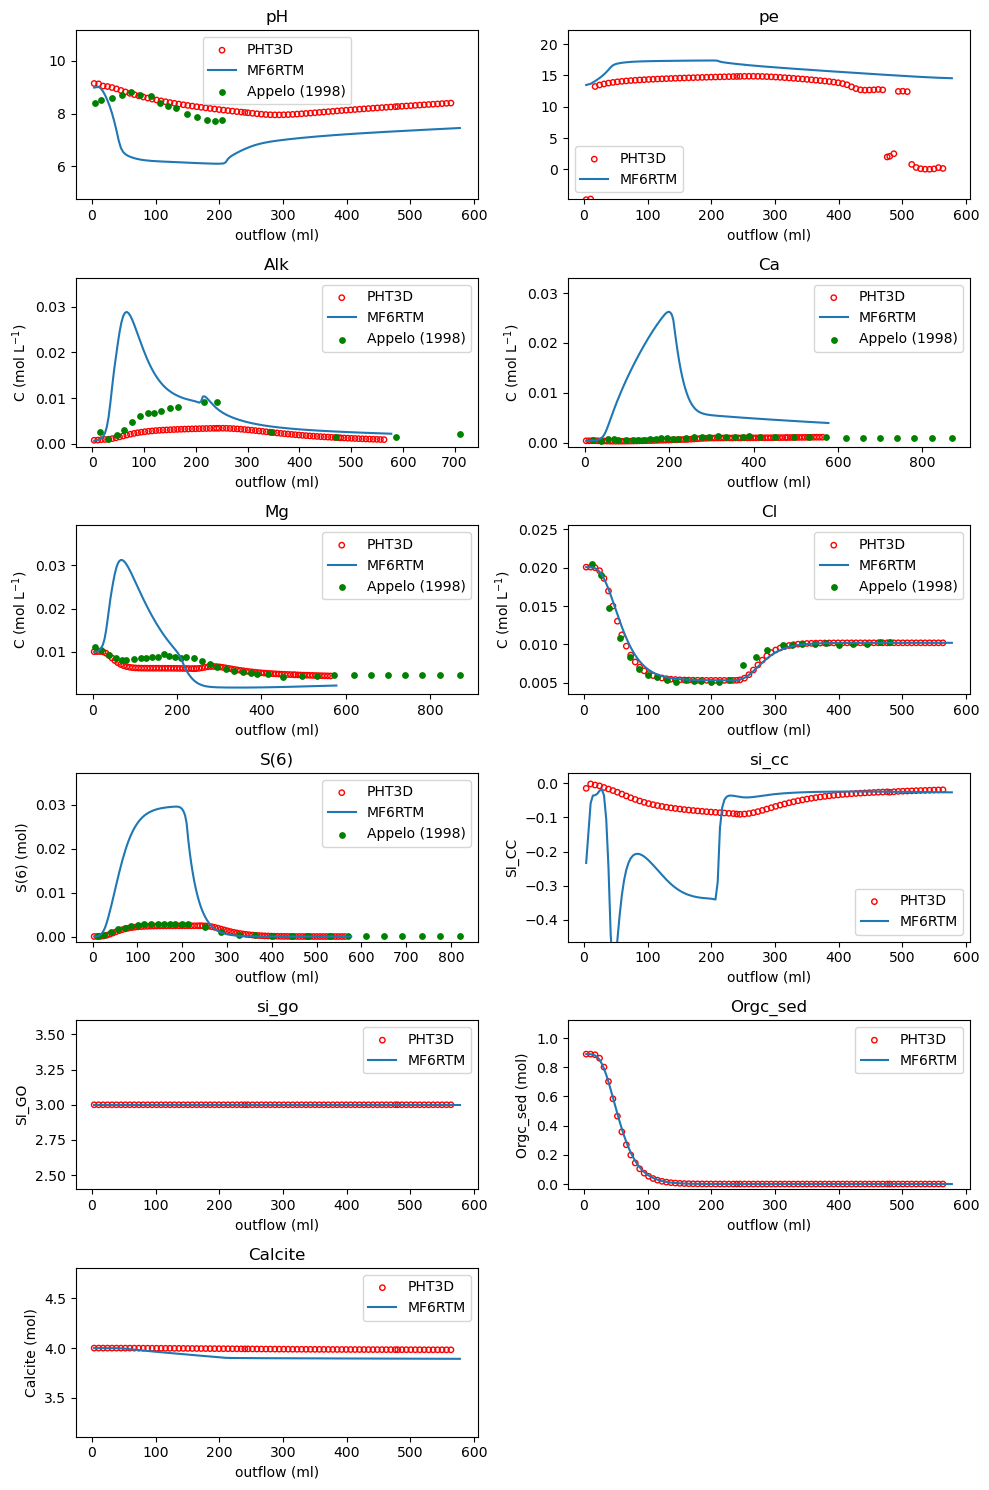

In [31]:
# plot comparison plots for pH, pe, Alkalinity, Ca, Mg, Cl, S(6), SI calcium carbonate, SI goethite, organic_sed, moles of calcite
pncol=2
variables = simapi.iloc[:,1:-1].columns #dissolved only
#q from m3/d to ml*3/d

qml = q*1000000

pnrow = calc_rows_from_ncol(variables, pncol)

fig, axs = plt.subplots(pnrow,pncol, figsize = (10, 15))
for var, ax in zip(variables, axs.flatten()):
    # print(ucndic[var][:,-1,0,-1])
    # ax.plot(simdf.x.unique(), simdf.loc[perlen, var], label = 'Engesgaard1992 - PHT3D')
    df = simapi[simapi['cell'] == simapi['cell'].max()].copy()
    dfpht3d = simdf[simdf['cell'] == simdf['cell'].max()].copy()
    t = df.index
    # ax.plot([x for x in timespht3d], ucndic[var][:,0,0,0], label = f'{prefix} - PHT3D')
    ax.scatter(dfpht3d.index[::2]*qml, dfpht3d[var][::2], label = f'PHT3D', facecolors='none', edgecolors='r', s=15)
    ax.plot(t*qml, df.loc[:, var], label = f'MF6RTM', 
              zorder = 10)
    if var in obs.columns:
        ax.scatter(obs.index, obs[var], label = 'Appelo (1998)', color='g', s = 15, zorder = 1)
    #get min and max of y axis
    xmin, xmax = ax.get_ylim()
    ax.set_ylim(xmin*.8, xmax*1.2)

    ax.set_xlabel('outflow (ml)')
    if var not in ['pH', 'pe'] and len(var) < 4:
        ax.set_ylabel('C (mol L$^{-1}$)')
    elif var.startswith('si'):
        ax.set_ylabel(f'{var.upper()}')
    elif len(var) > 3:
        ax.set_ylabel(f'{var} (mol)')
    ax.set_title(f'{var}')
    ax.ticklabel_format(useOffset=False)
    ax.legend()
#get rid of last subplot
if len(variables) % pncol:
    fig.delaxes(axs.flatten()[-1])
fig.tight_layout()
fig.savefig(os.path.join(f'{prefix}.png'))

# END

# Sandbox